# Data Prep + Feature Store
Hiring bias project - UCI Adult Income dataset

In [5]:
!pip install -U sagemaker pandas matplotlib --quiet

In [6]:
import sagemaker
import boto3
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import time

sess = sagemaker.Session()
region = sess.boto_region_name
role = sagemaker.get_execution_role()

bucket = "hiring-bias-adult-income-mustafa"  # change this to your own bucket name
prefix = "hiring-bias-project"

s3 = boto3.client("s3")

print(region)
print(role)
print(bucket)

us-east-1
arn:aws:iam::498374411846:role/service-role/AmazonSageMaker-ExecutionRole-20260619T141173
hiring-bias-adult-income-mustafa


In [7]:
# bucket might already exist from a previous run, don't want this to fail every time
try:
    if region == "us-east-1":
        s3.create_bucket(Bucket=bucket)
    else:
        s3.create_bucket(
            Bucket=bucket,
            CreateBucketConfiguration={"LocationConstraint": region},
        )
    print("created bucket:", bucket)
except s3.exceptions.BucketAlreadyOwnedByYou:
    print("bucket already exists, moving on")
except Exception as e:
    print(e)

created bucket: hiring-bias-adult-income-mustafa


In [8]:
# pulling the adult income dataset directly from UCI
train_url = "https://archive.ics.uci.edu/ml/machine-learning-databases/adult/adult.data"
test_url = "https://archive.ics.uci.edu/ml/machine-learning-databases/adult/adult.test"

columns = [
    "age", "workclass", "fnlwgt", "education", "education_num",
    "marital_status", "occupation", "relationship", "race", "sex",
    "capital_gain", "capital_loss", "hours_per_week", "native_country", "income"
]

train_df = pd.read_csv(train_url, names=columns, sep=r",\s*", engine="python", na_values="?")
test_df = pd.read_csv(test_url, names=columns, sep=r",\s*", engine="python", na_values="?", skiprows=1)

# test file has a trailing "." after the income label for some reason, gotta strip it
test_df["income"] = test_df["income"].str.replace(".", "", regex=False)

raw_df = pd.concat([train_df, test_df], ignore_index=True)
print(len(raw_df), "rows total")
raw_df.head()

48842 rows total


,age,workclass,fnlwgt,education,education_num,marital_status,occupation,relationship,race,sex,capital_gain,capital_loss,hours_per_week,native_country,income
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,<=50K
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,<=50K


In [9]:
raw_df.to_csv("adult_income_raw.csv", index=False)

raw_s3_path = sess.upload_data(
    path="adult_income_raw.csv",
    bucket=bucket,
    key_prefix=f"{prefix}/data/raw",
)
print(raw_s3_path)

s3://hiring-bias-adult-income-mustafa/hiring-bias-project/data/raw/adult_income_raw.csv


In [10]:
# quick sanity check before doing anything else
print(raw_df.shape)
print(raw_df.isna().sum())
print(raw_df["income"].value_counts(normalize=True))

(48842, 15)
age                  0
workclass         2799
fnlwgt               0
education            0
education_num        0
marital_status       0
occupation        2809
relationship         0
race                 0
sex                  0
capital_gain         0
capital_loss         0
hours_per_week       0
native_country     857
income               0
dtype: int64
income
<=50K    0.760718
>50K     0.239282
Name: proportion, dtype: float64


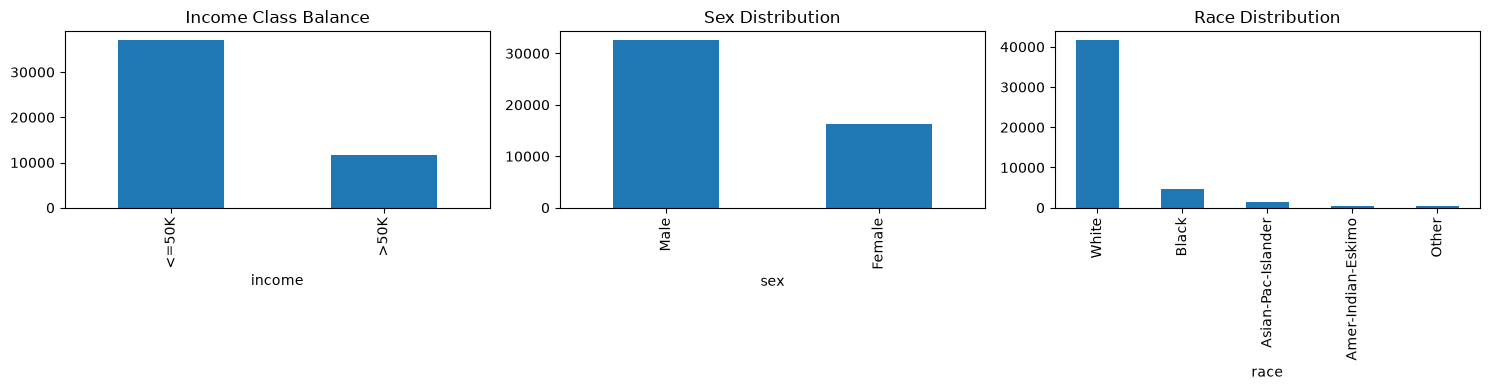

In [11]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

raw_df["income"].value_counts().plot(kind="bar", ax=axes[0], title="Income Class Balance")
raw_df["sex"].value_counts().plot(kind="bar", ax=axes[1], title="Sex Distribution")
raw_df["race"].value_counts().plot(kind="bar", ax=axes[2], title="Race Distribution")

plt.tight_layout()
plt.savefig("eda_distributions.png", dpi=100)
plt.show()

In [12]:
# checking income rate across protected groups now since this is what the
# fairness audit later is going to depend on
print("income > 50k rate by sex")
print(raw_df.groupby("sex")["income"].apply(lambda x: (x == ">50K").mean()))

print()
print("income > 50k rate by race")
print(raw_df.groupby("race")["income"].apply(lambda x: (x == ">50K").mean()))

income > 50k rate by sex
sex
Female    0.109251
Male      0.303767
Name: income, dtype: float64

income > 50k rate by race
race
Amer-Indian-Eskimo    0.117021
Asian-Pac-Islander    0.269256
Black                 0.120811
Other                 0.123153
White                 0.253987
Name: income, dtype: float64


In [13]:
from sklearn.model_selection import train_test_split

clean_df = raw_df.dropna().reset_index(drop=True)
clean_df["income_binary"] = (clean_df["income"] == ">50K").astype(int)

print(len(clean_df), "rows after dropping na, started with", len(raw_df))

# 70/15/15 split, stratified so the class balance holds across splits
train_val, test = train_test_split(
    clean_df, test_size=0.15, random_state=42, stratify=clean_df["income_binary"]
)
train, val = train_test_split(
    train_val, test_size=0.1765, random_state=42, stratify=train_val["income_binary"]
)

print("train:", len(train), "val:", len(val), "test:", len(test))

45222 rows after dropping na, started with 48842
train: 31653 val: 6785 test: 6784


In [14]:
train.to_csv("train.csv", index=False)
val.to_csv("validation.csv", index=False)
test.to_csv("test.csv", index=False)

for fname, split_name in [("train.csv", "train"), ("validation.csv", "validation"), ("test.csv", "test")]:
    s3_path = sess.upload_data(
        path=fname,
        bucket=bucket,
        key_prefix=f"{prefix}/data/{split_name}",
    )
    print(split_name, "->", s3_path)

train -> s3://hiring-bias-adult-income-mustafa/hiring-bias-project/data/train/train.csv
validation -> s3://hiring-bias-adult-income-mustafa/hiring-bias-project/data/validation/validation.csv
test -> s3://hiring-bias-adult-income-mustafa/hiring-bias-project/data/test/test.csv


In [15]:
from sagemaker.feature_store.feature_group import FeatureGroup
from sagemaker.feature_store.feature_definition import FeatureDefinition, FeatureTypeEnum
from time import gmtime, strftime

feature_group_name = "adult-income-features-" + strftime("%Y-%m-%d-%H-%M-%S", gmtime())
feature_group_name

'adult-income-features-2026-06-19-09-39-08'

In [16]:
# feature store needs a record id + event time column, neither of which exist yet
fs_df = clean_df.copy()
fs_df["record_id"] = fs_df.index.astype(str)
fs_df["event_time"] = pd.Timestamp.utcnow().isoformat()

for col in fs_df.columns:
    if fs_df[col].dtype == "object":
        fs_df[col] = fs_df[col].astype("str")

fs_df = fs_df.astype({
    "age": "int64",
    "fnlwgt": "int64",
    "education_num": "int64",
    "capital_gain": "int64",
    "capital_loss": "int64",
    "hours_per_week": "int64",
    "income_binary": "int64",
})

fs_df.head()

,age,workclass,fnlwgt,education,education_num,marital_status,occupation,relationship,race,sex,capital_gain,capital_loss,hours_per_week,native_country,income,income_binary,record_id,event_time
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K,0,0,2026-06-19T09:39:08.950626+00:00
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K,0,1,2026-06-19T09:39:08.950626+00:00
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K,0,2,2026-06-19T09:39:08.950626+00:00
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,<=50K,0,3,2026-06-19T09:39:08.950626+00:00
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,<=50K,0,4,2026-06-19T09:39:08.950626+00:00


In [17]:
feature_group = FeatureGroup(name=feature_group_name, sagemaker_session=sess)
feature_group.load_feature_definitions(data_frame=fs_df)

feature_group.create(
    s3_uri=f"s3://{bucket}/{prefix}/feature-store",
    record_identifier_name="record_id",
    event_time_feature_name="event_time",
    role_arn=role,
    enable_online_store=True,
)

print("creating feature group...")

creating feature group...


In [18]:
def wait_for_feature_group_creation(fg):
    status = fg.describe().get("FeatureGroupStatus")
    while status == "Creating":
        print("still creating...")
        time.sleep(10)
        status = fg.describe().get("FeatureGroupStatus")
    if status != "Created":
        raise RuntimeError(f"something went wrong, status was {status}")
    print("feature group ready:", fg.name)

wait_for_feature_group_creation(feature_group)

still creating...


feature group ready: adult-income-features-2026-06-19-09-39-08


In [19]:
# ingesting a 5k sample instead of the full ~45k rows, mostly to keep this fast.
# could ingest everything if needed later
sample_df = fs_df.sample(n=5000, random_state=42).reset_index(drop=True)

feature_group.ingest(data_frame=sample_df, max_workers=3, wait=True)
print("ingested", len(sample_df), "records")

ingested 5000 records


In [20]:
# pulling one record back out just to confirm it actually worked
featurestore_runtime = boto3.client("sagemaker-featurestore-runtime", region_name=region)

sample_record_id = sample_df.iloc[0]["record_id"]

response = featurestore_runtime.get_record(
    FeatureGroupName=feature_group_name,
    RecordIdentifierValueAsString=sample_record_id,
)
response["Record"][:5]

[{'FeatureName': 'age', 'ValueAsString': '28'},
 {'FeatureName': 'workclass', 'ValueAsString': 'Private'},
 {'FeatureName': 'fnlwgt', 'ValueAsString': '319768'},
 {'FeatureName': 'education', 'ValueAsString': 'Masters'},
 {'FeatureName': 'education_num', 'ValueAsString': '14'}]

In [22]:

print("bucket =", repr(bucket))
print("prefix =", repr(prefix))
print("feature_group_name =", repr(feature_group_name))
print("train_s3 =", repr(f"s3://{bucket}/{prefix}/data/train/train.csv"))
print("validation_s3 =", repr(f"s3://{bucket}/{prefix}/data/validation/validation.csv"))
print("test_s3 =", repr(f"s3://{bucket}/{prefix}/data/test/test.csv"))

bucket = 'hiring-bias-adult-income-mustafa'
prefix = 'hiring-bias-project'
feature_group_name = 'adult-income-features-2026-06-19-09-39-08'
train_s3 = 's3://hiring-bias-adult-income-mustafa/hiring-bias-project/data/train/train.csv'
validation_s3 = 's3://hiring-bias-adult-income-mustafa/hiring-bias-project/data/validation/validation.csv'
test_s3 = 's3://hiring-bias-adult-income-mustafa/hiring-bias-project/data/test/test.csv'
